# IEM Cologne 2026 — CS2 Major Predictor

End-to-end notebook: **collect CS2-only data → engineer features → train the stacked
ensemble → backtest → simulate the Major** (Stage 1/2/3 Swiss + single-elim playoffs)
and predict the champion.

It drives the reusable `iemcs` package end-to-end and shows the tables and charts inline.

> The first run clones the Valve Regional Standings repo into `data/raw/`
> (set the `VRS_REPO_DIR` env var to reuse an existing clone).

In [1]:
import os, sys

# Find the repo root (the folder containing the `iemcs` package) from any cwd.
_root = os.getcwd()
while not os.path.isdir(os.path.join(_root, "iemcs")) and _root != os.path.dirname(_root):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from iemcs import config, vrs, dataset, tournament, validate, report
from iemcs.model import MatchModel
from iemcs.config import FEATURE_COLUMNS
from iemcs.teams import FIELD

# `iemcs.report` forces the Agg backend on import; restore inline afterwards so the
# notebook's own plots render in the cells.
%matplotlib inline
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

N_SIMS = 50_000          # Monte-Carlo runs (the simulation is fast; tune freely)
print("iemcs loaded ·", len(FEATURE_COLUMNS), "engineered features ·", len(FIELD), "teams")

iemcs loaded · 11 engineered features · 32 teams


## 1 · Collect CS2-only data

The single source is Valve's official Regional Standings repo. Its per-team monthly
*details* files are parsed into deduplicated CS2 matches (no CS:GO), plus VRS points,
rosters and regions.

In [2]:
vrs.ensure_repo()
matches   = vrs.parse_matches()
standings = vrs.parse_standings()
region    = vrs.build_region_map()

print(f"{len(matches):,} CS2 matches   {matches.date.min().date()} -> {matches.date.max().date()}")
print(f"{standings.snapshot.nunique()} monthly VRS snapshots · {len(region)} teams with a region")
matches.head()

27,255 CS2 matches   2024-02-08 -> 2026-05-03
42 monthly VRS snapshots · 726 teams with a region


,date,winner,loser
0,2024-02-08,Nemiga,Sashi
1,2024-02-08,FORZE,BetBoom
2,2024-02-08,Insilio,ex-Guild Eagles
3,2024-02-08,AMKAL,RUBY
4,2024-02-09,Falcons,ENCE


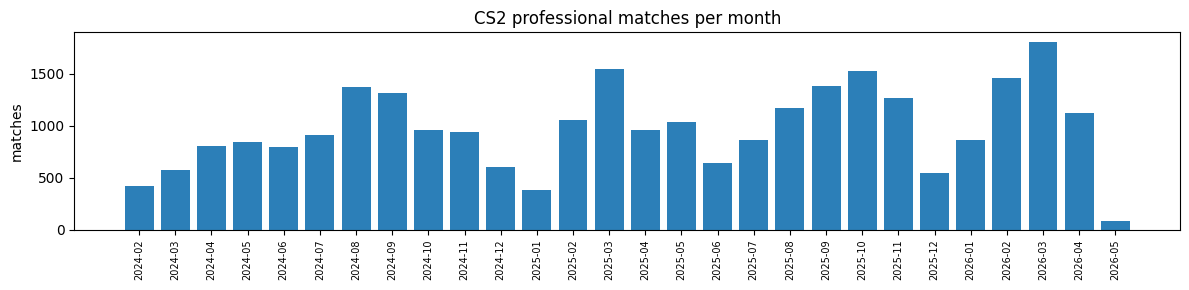

In [3]:
# Match volume over time (the training data)
mc = matches.set_index("date").resample("MS").size()
labels = [d.strftime("%Y-%m") for d in mc.index]
plt.figure(figsize=(12, 3))
plt.bar(range(len(mc)), mc.values, color="#2c7fb8")
plt.xticks(range(len(mc)), labels, rotation=90, fontsize=7)
plt.title("CS2 professional matches per month"); plt.ylabel("matches")
plt.tight_layout(); plt.show()

## 2 · Feature engineering (leak-free)

One chronological pass evolves each team's Elo, Glicko-2, form, streak, activity,
head-to-head and strength-of-schedule, recording *pre-match* features before observing
each result. The fitted `Context` then holds every team's present strength.

In [4]:
frame, ctx = dataset.build(matches, standings, region)
print("feature frame:", frame.shape, "| target balance:", round(frame.y.mean(), 3))
frame[FEATURE_COLUMNS + ["y"]].head()

feature frame: (27255, 19) | target balance: 0.497


,elo_diff,glicko_diff,glicko_rd_sum,vrs_diff,sos_diff,form_diff,h2h_diff,activity_diff,streak_diff,roster_stab_diff,same_region,y
0,0.0,0.0,700.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0
1,0.0,0.0,700.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,1
2,0.0,0.0,700.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0
3,0.0,0.0,700.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0
4,0.0,0.0,700.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,1


In [5]:
# Current strength of the 32-team field
cur  = vrs.current_standings()
cmap = dict(zip(cur.team, cur.points))
now  = matches.date.max()
ladder = pd.DataFrame([
    {"team": t.name, "stage": t.stage,
     "Elo": round(ctx.elo.rating(t.vrs_name)),
     "Glicko": round(ctx.glicko.rating(t.vrs_name)),
     "RD": round(ctx.glicko.rd(t.vrs_name)),
     "VRS": cmap.get(t.vrs_name, 1000)}
    for t in FIELD
]).sort_values("Elo", ascending=False).reset_index(drop=True)
ladder.head(12)

,team,stage,Elo,Glicko,RD,VRS
0,Vitality,3,2207,2246,67,2081
1,Falcons,3,2020,2056,62,1823
2,Spirit,2,2001,2069,65,1807
3,Natus Vincere,3,1994,2028,62,1885
4,9z,2,1939,1919,66,1508
5,FUT,2,1925,1948,62,1808
6,The MongolZ,3,1921,1981,63,1791
7,FURIA,3,1919,1991,63,1730
8,Astralis,2,1907,1935,61,1800
9,PARIVISION,3,1902,1957,62,1747


## 3 · Train the stacked ensemble

Base learners (logistic regression, random forest, hist-gradient-boosting) + the Elo /
Glicko-2 / VRS expectations are combined by a logistic meta-learner on out-of-fold
predictions, isotonically calibrated, with a cross-region VRS blend tuned on held-out
cross-region matches.

In [6]:
from iemcs.torch_model import _HAS_TORCH
model = MatchModel().fit(frame, verbose=True)
print("PyTorch MLP active:", _HAS_TORCH, "| base learners:", list(model.base))
pd.DataFrame({"member": model.stack_columns,
              "meta_weight": model.meta.coef_[0].round(3)})

  base learners: ['logreg', 'rf', 'gbm', 'knn', 'mlp']
  meta coefs   : elo_p=-0.46, glicko_p=+0.13, vrs_p=-0.13, logreg=+1.22, rf=+2.42, gbm=+0.39, knn=+1.14, mlp=+0.32
  OOF log-loss : stack=0.6136 calibrated=0.6116
  cross-region VRS blend w=0.40 (n_xr=1591); xr log-loss 0.6382 -> 0.6284
PyTorch MLP active: True | base learners: ['logreg', 'rf', 'gbm', 'knn', 'mlp']


,member,meta_weight
0,elo_p,-0.459
1,glicko_p,0.134
2,vrs_p,-0.132
3,logreg,1.223
4,rf,2.417
5,gbm,0.393
6,knn,1.143
7,mlp,0.321


## 4 · Backtest & feature importance

Walk-forward (train on the past, predict the next block) vs rating-only baselines, plus
the out-of-sample calibration curve and permutation feature importance.

In [7]:
bt = validate.backtest(frame, n_splits=3)
validate.print_report(bt)
pd.DataFrame({k: bt[k] for k in ["ensemble", "elo_only", "vrs_only"]}).T[
    ["accuracy", "log_loss", "brier", "auc", "n"]].round(4)

  fold 1: train=6816 test=6813 blend_w=0.00


  fold 2: train=13629 test=6813 blend_w=0.40


  fold 3: train=20442 test=6813 blend_w=0.35

=== Walk-forward backtest (out-of-sample) ===
model                          n     acc   logloss   brier     auc
------------------------------------------------------------------
ensemble                   20439   0.657    0.6305  0.2157   0.714
elo_only                   20439   0.639    0.6312  0.2208   0.694
vrs_only                   20439   0.571    0.7249  0.2577   0.597
ensemble_cross_region       2862   0.663    0.6090  0.2112   0.724
elo_cross_region            2862   0.623    0.6346  0.2229   0.680

ensemble beats Elo-only on log-loss by +0.0008 (PASS)


,accuracy,log_loss,brier,auc,n
ensemble,0.6575,0.6305,0.2157,0.7139,20439.0
elo_only,0.6391,0.6312,0.2208,0.6943,20439.0
vrs_only,0.5707,0.7249,0.2577,0.5971,20439.0


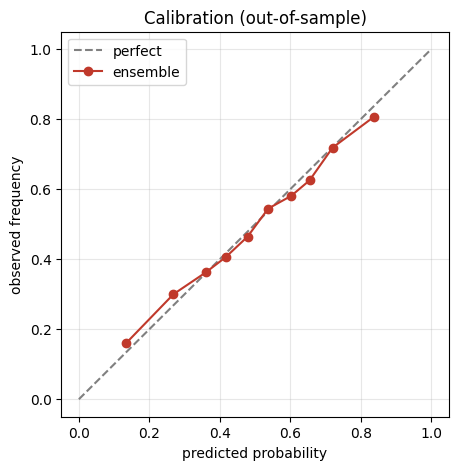

In [8]:
from sklearn.calibration import calibration_curve
y, p = bt["_reliability"]
frac, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
plt.plot(mean_pred, frac, "o-", color="#c0392b", label="ensemble")
plt.xlabel("predicted probability"); plt.ylabel("observed frequency")
plt.title("Calibration (out-of-sample)"); plt.legend(); plt.grid(alpha=.3); plt.show()

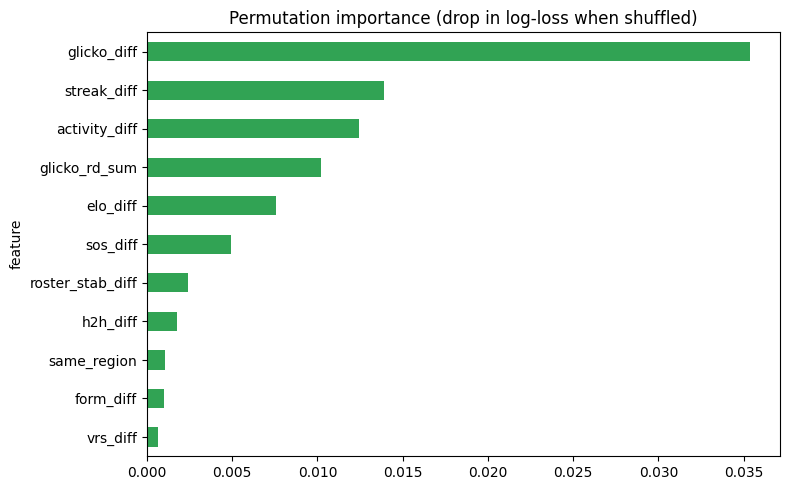

,feature,uni_AUC_gap,perm_importance
0,glicko_diff,0.2016,0.0354
1,streak_diff,0.0822,0.0139
2,activity_diff,0.1054,0.0124
3,glicko_rd_sum,0.0100,0.0102
4,elo_diff,0.1945,0.0076
5,sos_diff,0.0999,0.0049
6,roster_stab_diff,0.0586,0.0024
7,h2h_diff,0.0747,0.0017
8,same_region,0.0009,0.0011
9,form_diff,0.1197,0.0010


In [9]:
# Permutation importance + standalone AUC for each feature
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

k = int(len(frame) * 0.8)
tr, te = frame.iloc[:k], frame.iloc[k:]
gbm = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05, max_depth=4,
                                     l2_regularization=1.0, random_state=0)
gbm.fit(tr[FEATURE_COLUMNS], tr.y)
pi = permutation_importance(gbm, te[FEATURE_COLUMNS], te.y,
                            scoring="neg_log_loss", n_repeats=8, random_state=0)
imp = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "uni_AUC_gap": [abs(roc_auc_score(te.y, te[f]) - 0.5) for f in FEATURE_COLUMNS],
    "perm_importance": pi.importances_mean,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

ax = imp.set_index("feature")["perm_importance"].iloc[::-1].plot.barh(
    figsize=(8, 5), color="#31a354")
ax.set_title("Permutation importance (drop in log-loss when shuffled)")
plt.tight_layout(); plt.show()
imp.round(4)

## 4b · Model comparison — pre vs post ensemble

Out-of-sample (time-held-out last 20%) metrics for **each base learner on its own**, the
rating signals for reference, and the stacked ensemble **without** vs **with** the new
KNN member. Lower `log_loss`/`brier` and higher `auc`/`accuracy` are better.

The KNN member adds instance-based diversity; the `ENSEMBLE (no knn)` vs `ENSEMBLE
(full)` rows isolate its effect. Note that stacking buys *robust, calibrated*
probabilities rather than a guaranteed log-loss win on every split — on a single recent
window the strongest single model can edge it, and the cross-region VRS blend trades a
little raw log-loss for sanity in the *simulation* (it stops weak-region teams being
over-rated in the cross-region matchups that dominate a Major).

In [10]:
comp = validate.compare_models(frame, new_member="knn")
comp.round(4)

,accuracy,log_loss,brier,auc,n
mlp,0.6617,0.6109,0.2119,0.7239,5451.0
gbm,0.6564,0.6144,0.2133,0.7200,5451.0
rf,0.6520,0.6153,0.2139,0.7172,5451.0
logreg,0.6514,0.6204,0.2162,0.7093,5451.0
knn,0.6557,0.6219,0.2146,0.7162,5451.0
ENSEMBLE (full),0.6513,0.6259,0.2173,0.7103,5451.0
ENSEMBLE (no knn),0.6498,0.6263,0.2177,0.7086,5451.0
elo_p,0.6347,0.6296,0.2203,0.6947,5451.0
vrs_p,0.5825,0.7119,0.2524,0.6180,5451.0


## 5 · Simulate the Major

Build the per-map win-probability table for all 32 teams, then Monte-Carlo the full
format (three Swiss stages + single-elim playoffs) `N_SIMS` times.

In [11]:
vrs_pts = {t.name: float(cmap.get(t.vrs_name, 1000)) for t in FIELD}
pmap = tournament.build_pmap(model, ctx, now)
res  = tournament.run_monte_carlo(pmap, vrs_pts, n_sims=N_SIMS, n_jobs=-1)

assert abs(res.champion.sum() - 1) < 1e-6 and abs(res.adv_s3.sum() - 8) < 1e-6
disp = res[["stage", "vrs", "adv_s1", "adv_s2", "adv_s3",
            "semifinal", "final", "champion"]].copy()
for c in ["adv_s1", "adv_s2", "adv_s3", "semifinal", "final", "champion"]:
    disp[c] = (disp[c] * 100).round(1)
disp

,stage,vrs,adv_s1,adv_s2,adv_s3,semifinal,final,champion
team,,,,,,,,
Vitality,3,2081.0,NaN,NaN,97.9,83.3,70.7,63.3
Falcons,3,1823.0,NaN,NaN,78.6,44.6,22.4,7.9
Natus Vincere,3,1885.0,NaN,NaN,75.7,41.8,20.4,6.6
Spirit,2,1807.0,NaN,81.2,53.8,28.7,13.1,4.3
The MongolZ,3,1791.0,NaN,NaN,65.9,32.3,14.0,4.2
FURIA,3,1730.0,NaN,NaN,65.7,31.8,13.4,3.8
Aurora,3,1742.0,NaN,NaN,57.9,25.6,9.4,2.2
PARIVISION,3,1747.0,NaN,NaN,56.7,24.2,9.0,2.0
Astralis,2,1800.0,NaN,69.7,33.3,14.1,5.3,1.2


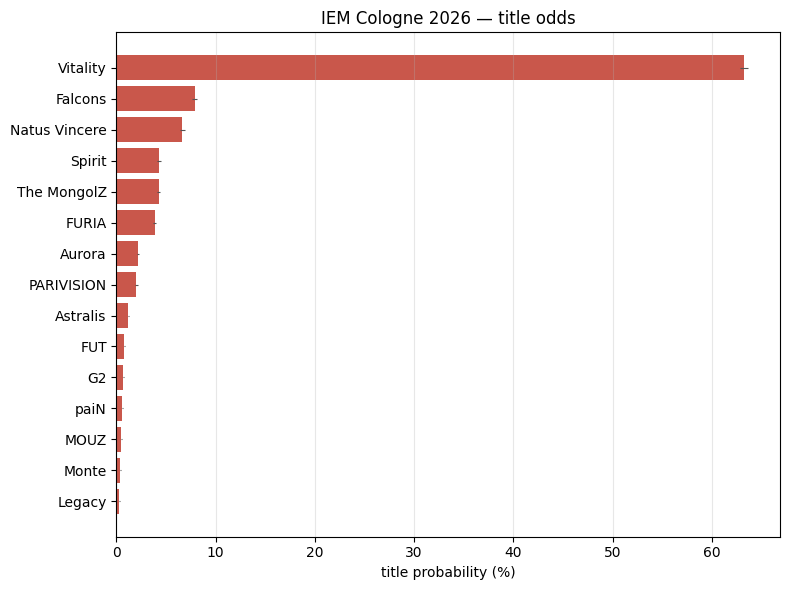

In [12]:
# Title odds with Monte-Carlo confidence intervals
top = res.sort_values("champion").tail(15)
plt.figure(figsize=(8, 6))
plt.barh(top.index, top.champion * 100,
         xerr=[(top.champion - top.champion_lo) * 100,
               (top.champion_hi - top.champion) * 100],
         color="#c0392b", alpha=.85, error_kw=dict(ecolor="#555", lw=.8))
plt.xlabel("title probability (%)"); plt.title("IEM Cologne 2026 — title odds")
plt.grid(axis="x", alpha=.3); plt.tight_layout(); plt.show()

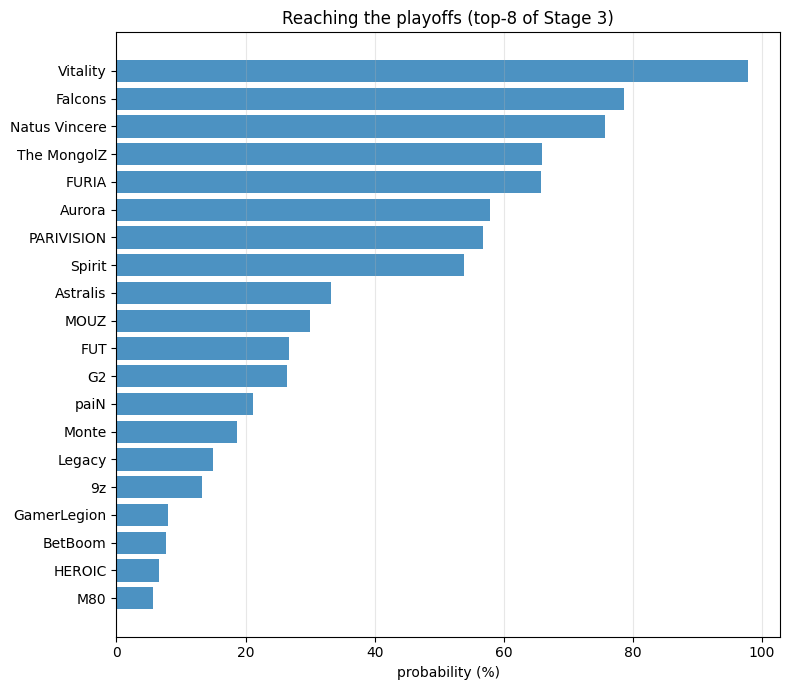

In [13]:
# Probability of reaching the playoffs (Stage 3 top-8)
po = res.sort_values("adv_s3").tail(20)
plt.figure(figsize=(8, 7))
plt.barh(po.index, po.adv_s3 * 100, color="#2c7fb8", alpha=.85)
plt.xlabel("probability (%)"); plt.title("Reaching the playoffs (top-8 of Stage 3)")
plt.grid(axis="x", alpha=.3); plt.tight_layout(); plt.show()

In [14]:
# Persist the full set of artifacts (CSVs, charts, markdown report)
bt_clean = {k: v for k, v in bt.items() if k != "_reliability"}
csvs   = report.save_csvs(res)
charts = report.charts(res)
md_out = report.write_markdown(res, bt_clean)
print(f"Saved {len(csvs)} CSVs and {len(charts)} charts to {config.OUTPUTS_DIR}")
print("Report:", md_out)

Saved 5 CSVs and 4 charts to /mnt/c/Users/sharp/Documents/GitHub/iemcologne2026/outputs
Report: /mnt/c/Users/sharp/Documents/GitHub/iemcologne2026/outputs/REPORT.md


## Notes

- **Vitality** emerge as a heavy favourite because they were dominant across the
  2024–2026 CS2 data the model trains on — it reflects the data, not a hand-set prior.
  Raise `PROB_SHRINK` in `iemcs/config.py` to add upset variance.
- Re-running top-to-bottom closer to the event folds in the latest VRS update and rosters.
- All logic lives in the reusable `iemcs` package; this notebook is the single entry point.